In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv("C:\\Users\\ericl\\Downloads\\Lending Club Loan Dataset 2007_2011\\loan.csv")

C:\Users\ericl\AppData\Local\Temp\ipykernel_20220\2520812115.py:1: DtypeWarning: Columns (47) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv("C:\\Users\\ericl\\Downloads\\Lending Club Loan Dataset 2007_2011\\loan.csv")


In [3]:
#analysing 
print("Size of dataset")
print(df.shape)
print()
print("List of columns")
print(df.columns)
print()
print("Dataset sample")
print(df.head())
print()
print("Columns data types")
print(df.dtypes)

Size of dataset
(39717, 111)

List of columns
Index(['id', 'member_id', 'loan_amnt', 'funded_amnt', 'funded_amnt_inv',
       'term', 'int_rate', 'installment', 'grade', 'sub_grade',
       ...
       'num_tl_90g_dpd_24m', 'num_tl_op_past_12m', 'pct_tl_nvr_dlq',
       'percent_bc_gt_75', 'pub_rec_bankruptcies', 'tax_liens',
       'tot_hi_cred_lim', 'total_bal_ex_mort', 'total_bc_limit',
       'total_il_high_credit_limit'],
      dtype='object', length=111)

Dataset sample
        id  member_id  loan_amnt  funded_amnt  funded_amnt_inv        term  \
0  1077501    1296599       5000         5000           4975.0   36 months   
1  1077430    1314167       2500         2500           2500.0   60 months   
2  1077175    1313524       2400         2400           2400.0   36 months   
3  1076863    1277178      10000        10000          10000.0   36 months   
4  1075358    1311748       3000         3000           3000.0   60 months   

  int_rate  installment grade sub_grade  ... num_tl

In [4]:
# check for missing values
print("Missing values per column:")
print(df.isna().sum().sort_values(ascending=False).head(10))

Missing values per column:
verification_status_joint    39717
annual_inc_joint             39717
mo_sin_old_rev_tl_op         39717
mo_sin_old_il_acct           39717
bc_util                      39717
bc_open_to_buy               39717
avg_cur_bal                  39717
acc_open_past_24mths         39717
inq_last_12m                 39717
total_cu_tl                  39717
dtype: int64


In [5]:
#remove columns with more than 50% missing values
df_clean=df.dropna(axis=1,thresh = len(df) * 0.5)
# fill the income NAs with the income median
df_clean["annual_inc"] = df_clean["annual_inc"].fillna(df_clean["annual_inc"].median()).copy()

C:\Users\ericl\AppData\Local\Temp\ipykernel_20220\2622745751.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_clean["annual_inc"] = df_clean["annual_inc"].fillna(df_clean["annual_inc"].median()).copy()


In [6]:
df_clean["loan_status"].value_counts()

loan_status
Fully Paid     32950
Charged Off     5627
Current         1140
Name: count, dtype: int64

In [7]:
# "Current" does not give us information about whether the loan was paid off or not, so we will remove those rows from the dataset.
df_target = df_clean[df_clean["loan_status"].isin(["Fully Paid", "Charged Off"])].copy()

#transform the interest rate column to a float type by removing the % sign and converting to float
df_target["int_rate"] = df_target["int_rate"].str.rstrip("%").astype(float)

In [8]:
# verify relationship between grade and loan amount. There seems to be a positive correlation between the two, with higher grades having higher loan amounts.
print("Loan amount statistics by grade:")
df_target.groupby("grade")["loan_amnt"].agg(["mean","median","max"])

Loan amount statistics by grade:


,mean,median,max
grade,,,
A,8618.758089,7500.0,35000
B,10934.783726,10000.0,35000
C,10815.518892,9600.0,35000
D,12137.767945,10000.0,35000
E,15680.116410,15000.0,35000
F,18095.235656,18000.0,35000
G,20253.010033,20500.0,35000


In [9]:
# verify relationship between grade and loan status. As expected,the worse the grade, the higher the chance of defaulting on the loan.
print("Loan status distribution by grade:")
df_target.groupby("grade")["loan_status"].value_counts(normalize=True)

Loan status distribution by grade:


grade  loan_status
A      Fully Paid     0.940070
       Charged Off    0.059930
B      Fully Paid     0.877944
       Charged Off    0.122056
C      Fully Paid     0.828057
       Charged Off    0.171943
D      Fully Paid     0.780138
       Charged Off    0.219862
E      Fully Paid     0.731506
       Charged Off    0.268494
F      Fully Paid     0.673156
       Charged Off    0.326844
G      Fully Paid     0.662207
       Charged Off    0.337793
Name: proportion, dtype: float64

In [10]:
# transform the issue date into a datetime object and extract the year and month for further analysis
df_target["issue_d"] = pd.to_datetime(df_target["issue_d"], format="%b-%y")

df_target["issue_year"] = df_target["issue_d"].dt.year
df_target["issue_month"] = df_target["issue_d"].dt.month

df_target.groupby("issue_year")["loan_amnt"].sum()

issue_year
2007      2219275
2008     14390275
2009     46436325
2010    122050200
2011    241065025
Name: loan_amnt, dtype: int64

In [11]:
# analyse which purpose of loan has the highest default rate. As expected, loans for small businesses have the highest 
# default rate, but interestingly renewable energy and educational loans come second and third.
default_rates = df_target.groupby("purpose")["loan_status"].value_counts(normalize = True).unstack().sort_values("Charged Off",ascending = False)
default_rates

loan_status,Charged Off,Fully Paid
purpose,,
small_business,0.270810,0.729190
renewable_energy,0.186275,0.813725
educational,0.172308,0.827692
other,0.163777,0.836223
house,0.160763,0.839237
moving,0.159722,0.840278
medical,0.155653,0.844347
debt_consolidation,0.153254,0.846746
vacation,0.141333,0.858667


In [12]:
df_target.groupby("issue_year")["loan_amnt"].sum().sort_values(ascending=False)

issue_year
2011    241065025
2010    122050200
2009     46436325
2008     14390275
2007      2219275
Name: loan_amnt, dtype: int64

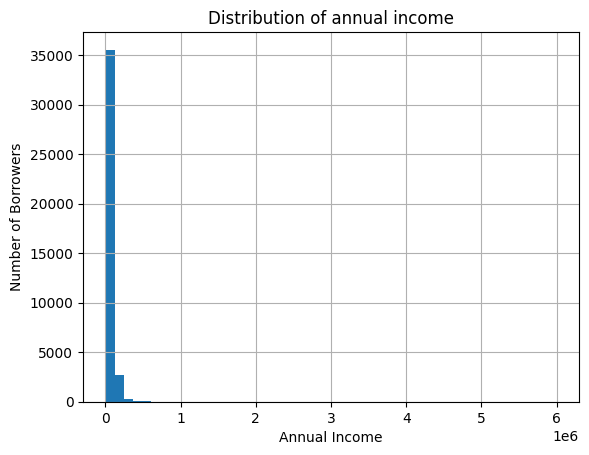

In [13]:
#verify the distribution of annual income. The distribution is right-skewed, with most borrowers having an annual income below $100,000.
df_target["annual_inc"].hist(bins=50)
plt.xlabel("Annual Income")
plt.ylabel("Number of Borrowers")
plt.title("Distribution of annual income")
plt.show()

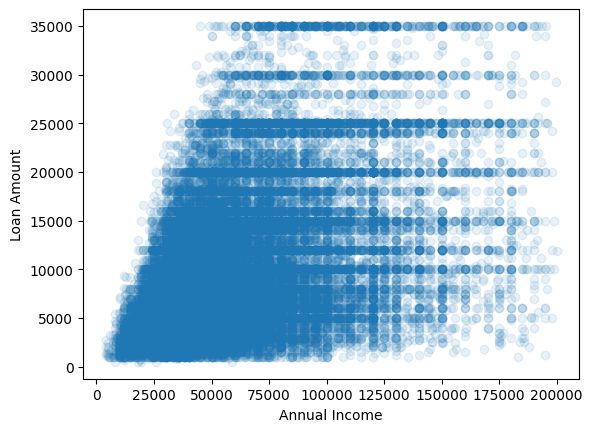

In [14]:
#outliers in annual income can skew the analysis, so we will zoom in on borrowers with an annual income below $200,000.
# a few things to note about the scatter plot: higher income is required for higher loan amounts, 
# but there are also many borrowers with high income who take out small loans.
#Additionally, loans tend to be given in round numbers, with many borrowers taking out loans of $5,000, $10,000, $15,000, etc.
zoomed = df_target[df_target["annual_inc"] < 200000].copy()

plt.scatter(zoomed["annual_inc"], zoomed["loan_amnt"], alpha = 0.1)
plt.xlabel("Annual Income")
plt.ylabel("Loan Amount")
plt.show()


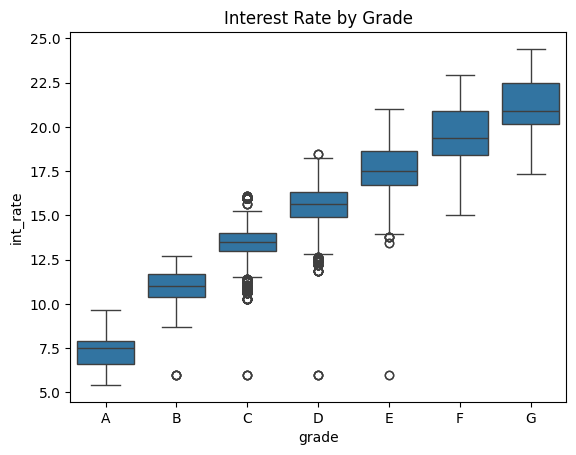

In [15]:
# as expected, worse grades have higher interest rates. Grades B to E seem to have outliers with interest around 6%
grade_order = sorted(df_target["grade"].unique())

plt.figure()
sns.boxplot(data=df_target, x="grade", y="int_rate", order=grade_order)
plt.title("Interest Rate by Grade")
plt.show()

In [16]:
# confirmed: there seem to be a few loans with interest rates around 6% for grades B to E. 
# 6% seems to be the minimum interest rate for these grades
df_target[(df_target["int_rate"] <= 6.0) & (df_target["grade"].isin(["B","C","D","E"]))].groupby("grade")["int_rate"].value_counts()

grade  int_rate
B      6.0         5
C      6.0         4
D      6.0         4
E      6.0         2
Name: count, dtype: int64

In [17]:
#turn grade numeric for correlation analysis. A is the best grade, so we will assign it a value of 1, B a value of 2, and so on.
grade_map = {"A": 1, "B": 2, "C": 3, "D": 4, "E": 5, "F": 6, "G": 7}
df_target["grade_numeric"] = df_target["grade"].map(grade_map)

numeric_cols=["loan_amnt", "int_rate", "annual_inc", "dti", "installment", "grade_numeric"]

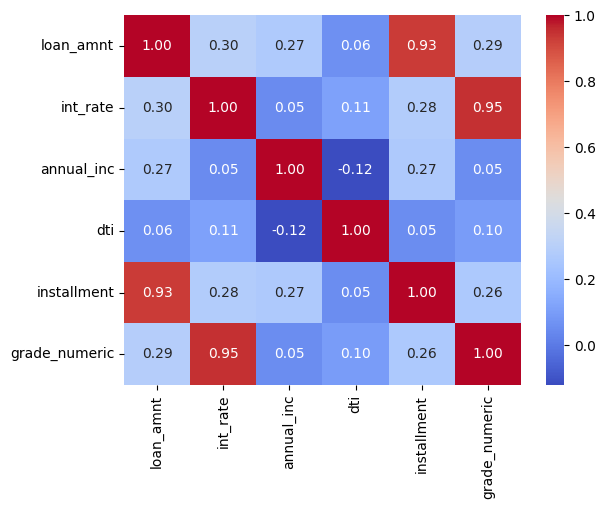

In [18]:
# strong correlation between interest rate and grade, as expected. 
# There is also a strong correlation between loan amount and installment, 
# which makes sense since the installment is calculated based on the loan amount.
corr_matrix = df_target[numeric_cols].corr()

sns.heatmap(corr_matrix, annot=True, cmap="coolwarm", fmt=".2f")
plt.show()